## DERIVATIVE PRICING
MODULE 6 | LESSON 1


---


# **IMPLIED VOLATILITY AND VOLATILITY SMILE**



|  |  |
|:---|:---|
|**Reading Time** |  50 minutes |
|**Prior Knowledge** | Black-Scholes, Volatility, Greeks |
|**Keywords** | Implied volatility, Volatility Smile, Newton-Raphson |


---

*In this lesson, we will guide you through the entire process of constructing the volatility smile, using data from Yahoo finance Option's chains. The option chains feature of Yahoo finance contains comprehensive data on exchange-traded options (both calls and puts) on an underlying stock. Interestingly for us at this point, it also already contains the Black-Scholes implied volatility for each of the different options and strikes.*

*Make sure you understand how to work with this data, as it will be an important source of information for the remainder of the course, as well as the Stochastic Modeling course. Specifically, we are going to use data on implied volatility to properly calibrate our models to market data.*

*So, let's get started!*


## 1. Working with Volatility Data and the Smile

First, we are going to import the necessary libraries.

In [1]:
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt

Next, we will work with option chain data for a particular stock—in this case, **IBM**. The spot price of IBM at the time the data was gathered was **214.23**.

There are several important considerations when working with options market data in real life applications:

- The implied volatility smile is typically more meaningful for stocks with higher volumes of exchange-traded options.

- When selecting option contracts, choose a maturity that is neither too close nor too far in the future. A good rule of thumb is to pick an expiration date roughly **three months ahead**.

- Ensure you select an exact expiration date. Since options do not expire every day, trying to use a non-existent date will result in an error.

- Implied volatility can be obtained from either call or put options. Even for the same strike, the implied volatility may differ slightly between calls and puts.

In the following example, we will use IBM's option chain data.

> ⚠️ Note: The implied volatility values will typically be available only when the U.S. markets are open in many data providers.


In [2]:
chain = pd.read_excel("Options_chain.xlsx", sheet_name=['Calls', 'Puts'])
df_call=chain['Calls']
df_put=chain['Puts']
price = 214.23

Once we have extracted the data from the implied volatility of the call options, let's see whether there is a smile:

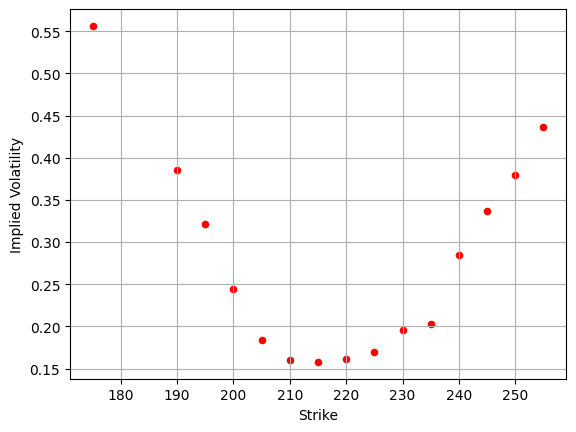

In [3]:
df_call = df_call[df_call["Implied Volatility"] > 0]
df_call["Strike"] = df_call["Strike"].astype(float)
df_call = df_call[
    df_call["Strike"] > price * 0.8
]  # We will only consider those options within a certain range of the current price
df_call = df_call[
    df_call["Strike"] < price * 1.2
]  # One reason for this is that it is precisely those options that are most often traded.


df_call.plot(kind="scatter", x="Strike", y="Implied Volatility", color="red")
plt.grid()
plt.show()

Here, you can see it is not really a complete smile. This is also called the volatility smirk (or skew). This arises when the volatility curve exhibits skewness. There are several explanations for this, mostly related to the increased demand of near ATM options from investors and put options to hedge against crashes.

\
And we can do the same process for put option data:<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

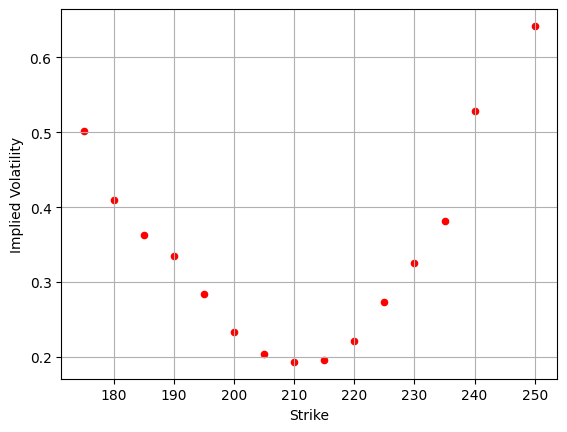

In [4]:
df_put = df_put[df_put["Implied Volatility"] > 0]
df_put["Strike"] = df_put["Strike"].astype(float)
df_put = df_put[df_put["Strike"] > price * 0.8]
df_put = df_put[df_put["Strike"] < price * 1.2]

df_put.plot(kind="scatter", x="Strike", y="Implied Volatility", color="red")
plt.grid()
plt.show()

Great! You now know how to extract data regarding options' implied volatility from Yahoo finance and how to graph the volatility smile (or smirk). 

## 2. The Newton-Raphson Method

Up to this point, we have worked with implied volatility data provided by Yahoo finance options chain data. This is essentially extracted from the BS model in the same way we have mentioned in the slides.

A convenient method to extract implied volatility data is the **Newton-Raphson recursive method**. As explained in the accompanying slides and video, this is essentially a method relying on iteration. In this last part of the notebook, we will see how to implement this method in practice.

As always, here are some necessary libraries and definitions to use later on:

In [5]:
import numpy as np
from scipy.stats import norm

N_prime = norm.pdf
N = norm.cdf

Then, we will need to define a few functions to simplify the task. Remember that under the Newton-Raphson method we will be iterating and updating our volatility parameter, $\sigma$, according to:

$\sigma_{i+1} = \sigma_i - \frac{f(\sigma_i)}{f'(\sigma_i)}, \ ∀ i \geq 0 $


We'll start by defining the objective function of the optimization, $f(\sigma_i)$, the Black-Scholes pricing equation:

In [6]:
def black_scholes_call(S, K, T, r, sigma):
    """
    :param S: Asset price
    :param K: Strike price
    :param T: Time to maturity
    :param r: risk-free rate (treasury bills)
    :param sigma: volatility
    :return: call price
    """

    # Black-Scholes Formula
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call = S * N(d1) - N(d2) * K * np.exp(-r * T)
    return call

Next, we'll define $f'(\sigma_i)$, which is basically the `vega` of the option:

In [7]:
def vega(S, K, T, r, sigma):
    """

    :param S: Asset price
    :param K: Strike price
    :param T: Time to Maturity
    :param r: risk-free rate (treasury bills)
    :param sigma: volatility
    :return: partial derivative w.r.t volatility
    """

    # Calculating d1 from black scholes
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    vega = S * np.sqrt(T) * N_prime(d1)
    return vega

Finally, we build our recursive process in the `implied_volatility_call` function for a given level of tolerance ($ϵ$) and a maximum number of iterations:

In [8]:
def implied_volatility_call(C, S, K, T, r, tol=0.0001, max_iterations=100):
    """

    :param C: Observed call price
    :param S: Asset price
    :param K: Strike Price
    :param T: Time to Maturity
    :param r: risk free rate
    :param tol: error tolerance in result
    :param max_iterations: max iterations to update vol
    :return: implied volatility in percent
    """

    # assigning initial volatility estimate for input in Newton_rap procedure
    sigma = 0.3

    for i in range(max_iterations):
        # calculate difference between black-scholes price and market price with
        # iteratively updated volatility estimate
        diff = black_scholes_call(S, K, T, r, sigma) - C
        print(i)
        # break if difference is less than specified tolerance level
        if abs(diff) < tol:
            print(f"found on {i+1}th iteration")
            print(f"difference is equal to {diff}")
            break

        # use Newton-Rapshon to update the estimate
        sigma = sigma - diff / vega(S, K, T, r, sigma)

    return sigma

So, let's check how our algorithm performs. Imagine we observe a call option with a price of \\$18: The current stock price is $S=100$; strike price $K=115$; there is one year until maturity (T); and the risk-free rate is $r=0.05$.

In [9]:
observed_price = 18
S = 100
K = 115
T = 1
r = 0.05

imp_vol = implied_volatility_call(observed_price, S, K, T, r)
print("Implied volatility using Newton Rapshon is: ", imp_vol)

0
1
2
found on 3th iteration
difference is equal to -7.274655111189077e-06
Implied volatility using Newton Rapshon is:  0.5428424065162358


You can check the performance of this algorithm against some of the existing (freely available) online implied volatility calculators. For example, [you can check this site.](http://www.option-price.com/implied-volatility.php)

Try playing around with the different parameters to see if you obtain the same numbers with your algorithm and the online calculator. Note that very small differences can arise due to tolerance levels. 

## 3. Conclusion

Well done! Now you know a simple way to extract implied volatility from option market prices. In the next lesson, we will move on to models that allow for variability in the volatility parameters. We'll check whether we can replicate the smile with those models, or even if there is "only" a smile, that is, if the difference in implied volatility only varies with the strike term. 

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
